<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Variation: Single star evolution</p>
    <o style='font-size:20px;'>How does removing binary interactions after BHs?</p>
</div>

In [2]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.interpolate import interp1d
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Load data

In [3]:
files = ["fiducial", "singles"]
labels = ["Binaries", "Singles"]
colours = ["#333", "#96B73B"]

pops, data = helpers.load_postprocessed_pops(files, labels, colours)
binaries, singles = pops

Loading post-processed data for Binaries from fiducial
Loading post-processed data for Singles from singles


# Totals

Singles
  Total: 6530004, NSs: 4792082, BHs: 1737922
Binaries
  Total: 6989033, NSs: 5185407, BHs: 1803626


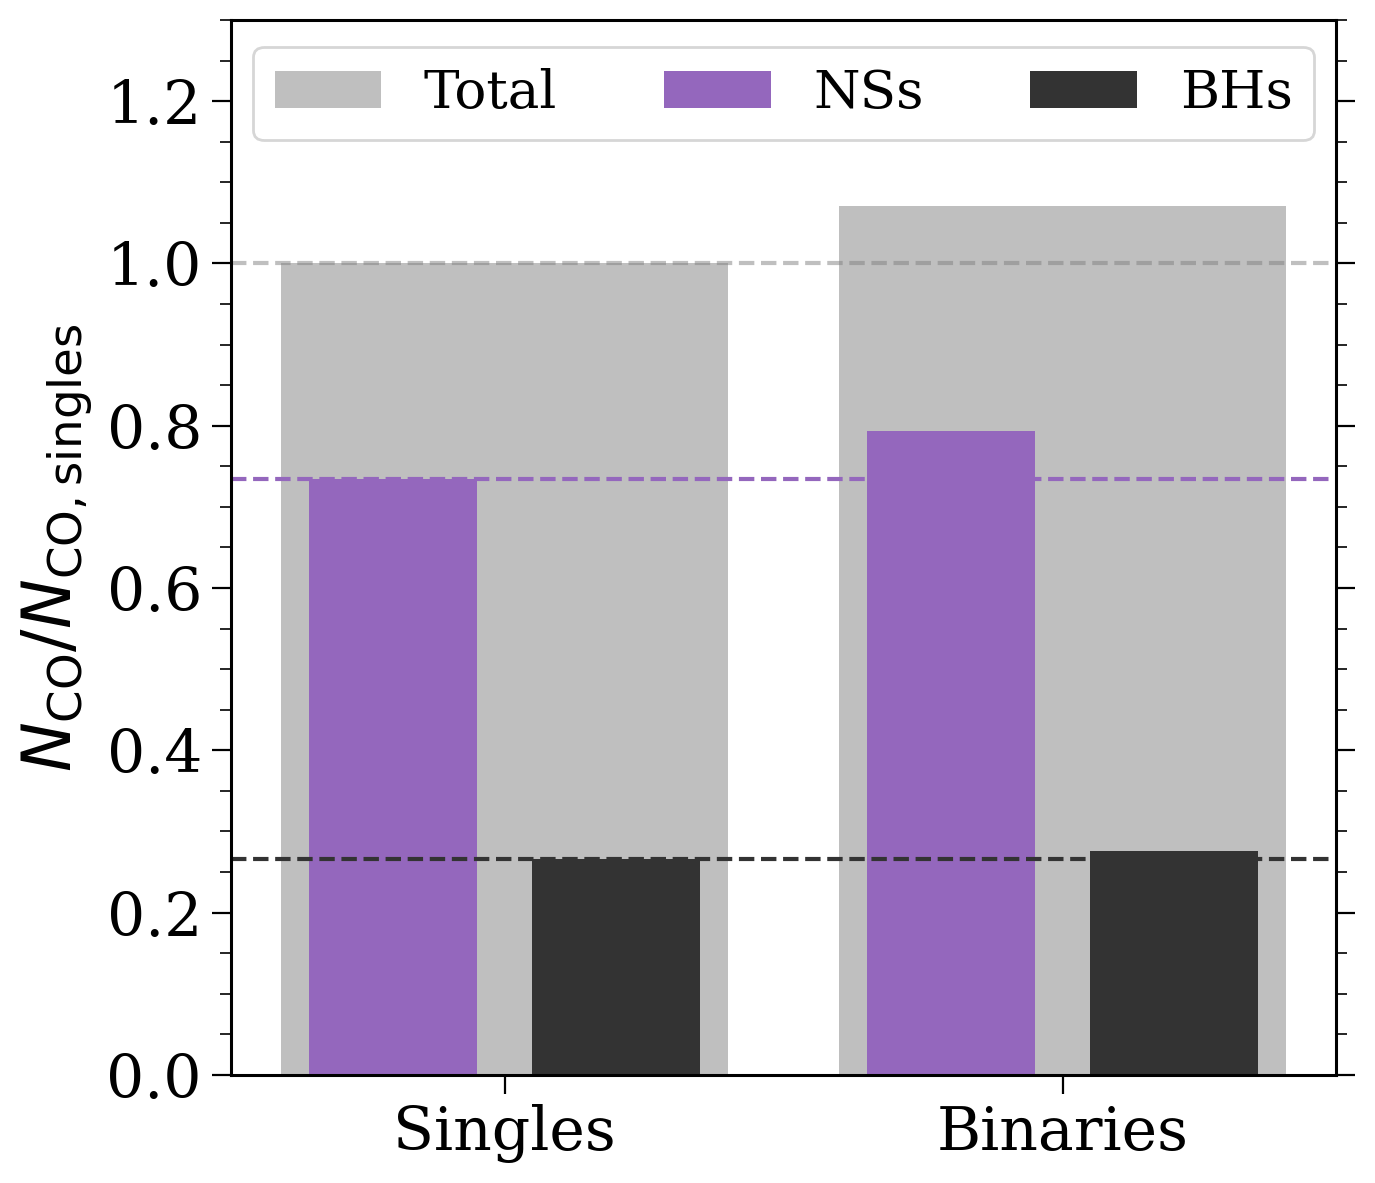

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

total_single_cos = None

pops = [singles, binaries]

for i, pop in enumerate(pops):
    n_ns = len(data[pop.label]["mass"]["NS"])
    n_bh = len(data[pop.label]["mass"]["BH"])
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")

    if total_single_cos is None and pop.label.startswith("Singles"):
        total_single_cos = n_ns + n_bh

    ax.bar(i, (n_ns + n_bh) / total_single_cos, label="Total" if i == 0 else None, color="grey", alpha=0.5)
    ax.bar(i - 0.2, n_ns / total_single_cos, width=0.3, label="NSs" if i == 0 else None, color="tab:purple")
    ax.bar(i + 0.2, n_bh / total_single_cos, width=0.3, label="BHs" if i == 0 else None, color="#333")

    if i == 0:
        ax.axhline((n_ns + n_bh) / total_single_cos, color="grey", alpha=0.5, ls='--')
        ax.axhline(n_ns / total_single_cos, color="tab:purple", ls='--')
        ax.axhline(n_bh / total_single_cos, color="#333", ls='--')


ax.set_xticks(range(len(pops)), [pop.label for pop in pops])
ax.set_ylabel(r"$N_{\rm CO} / N_{\rm CO, singles}$")
ax.legend(ncol=3, loc='upper center', fontsize=0.8*fs)

ax.set(
    ylim=(0, 1.3),
)

ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# show yticks on both sides
ax.yaxis.set_ticks_position('both')

plt.tight_layout()
plt.show()

# Mass distributions

In [8]:
f'{data["Binaries"]["mass"]["BH"].sum() / data["Singles"]["mass"]["BH"].sum():1.2f}x more mass in BHs in binaries vs singles'

'1.03x more mass in BHs in binaries vs singles'

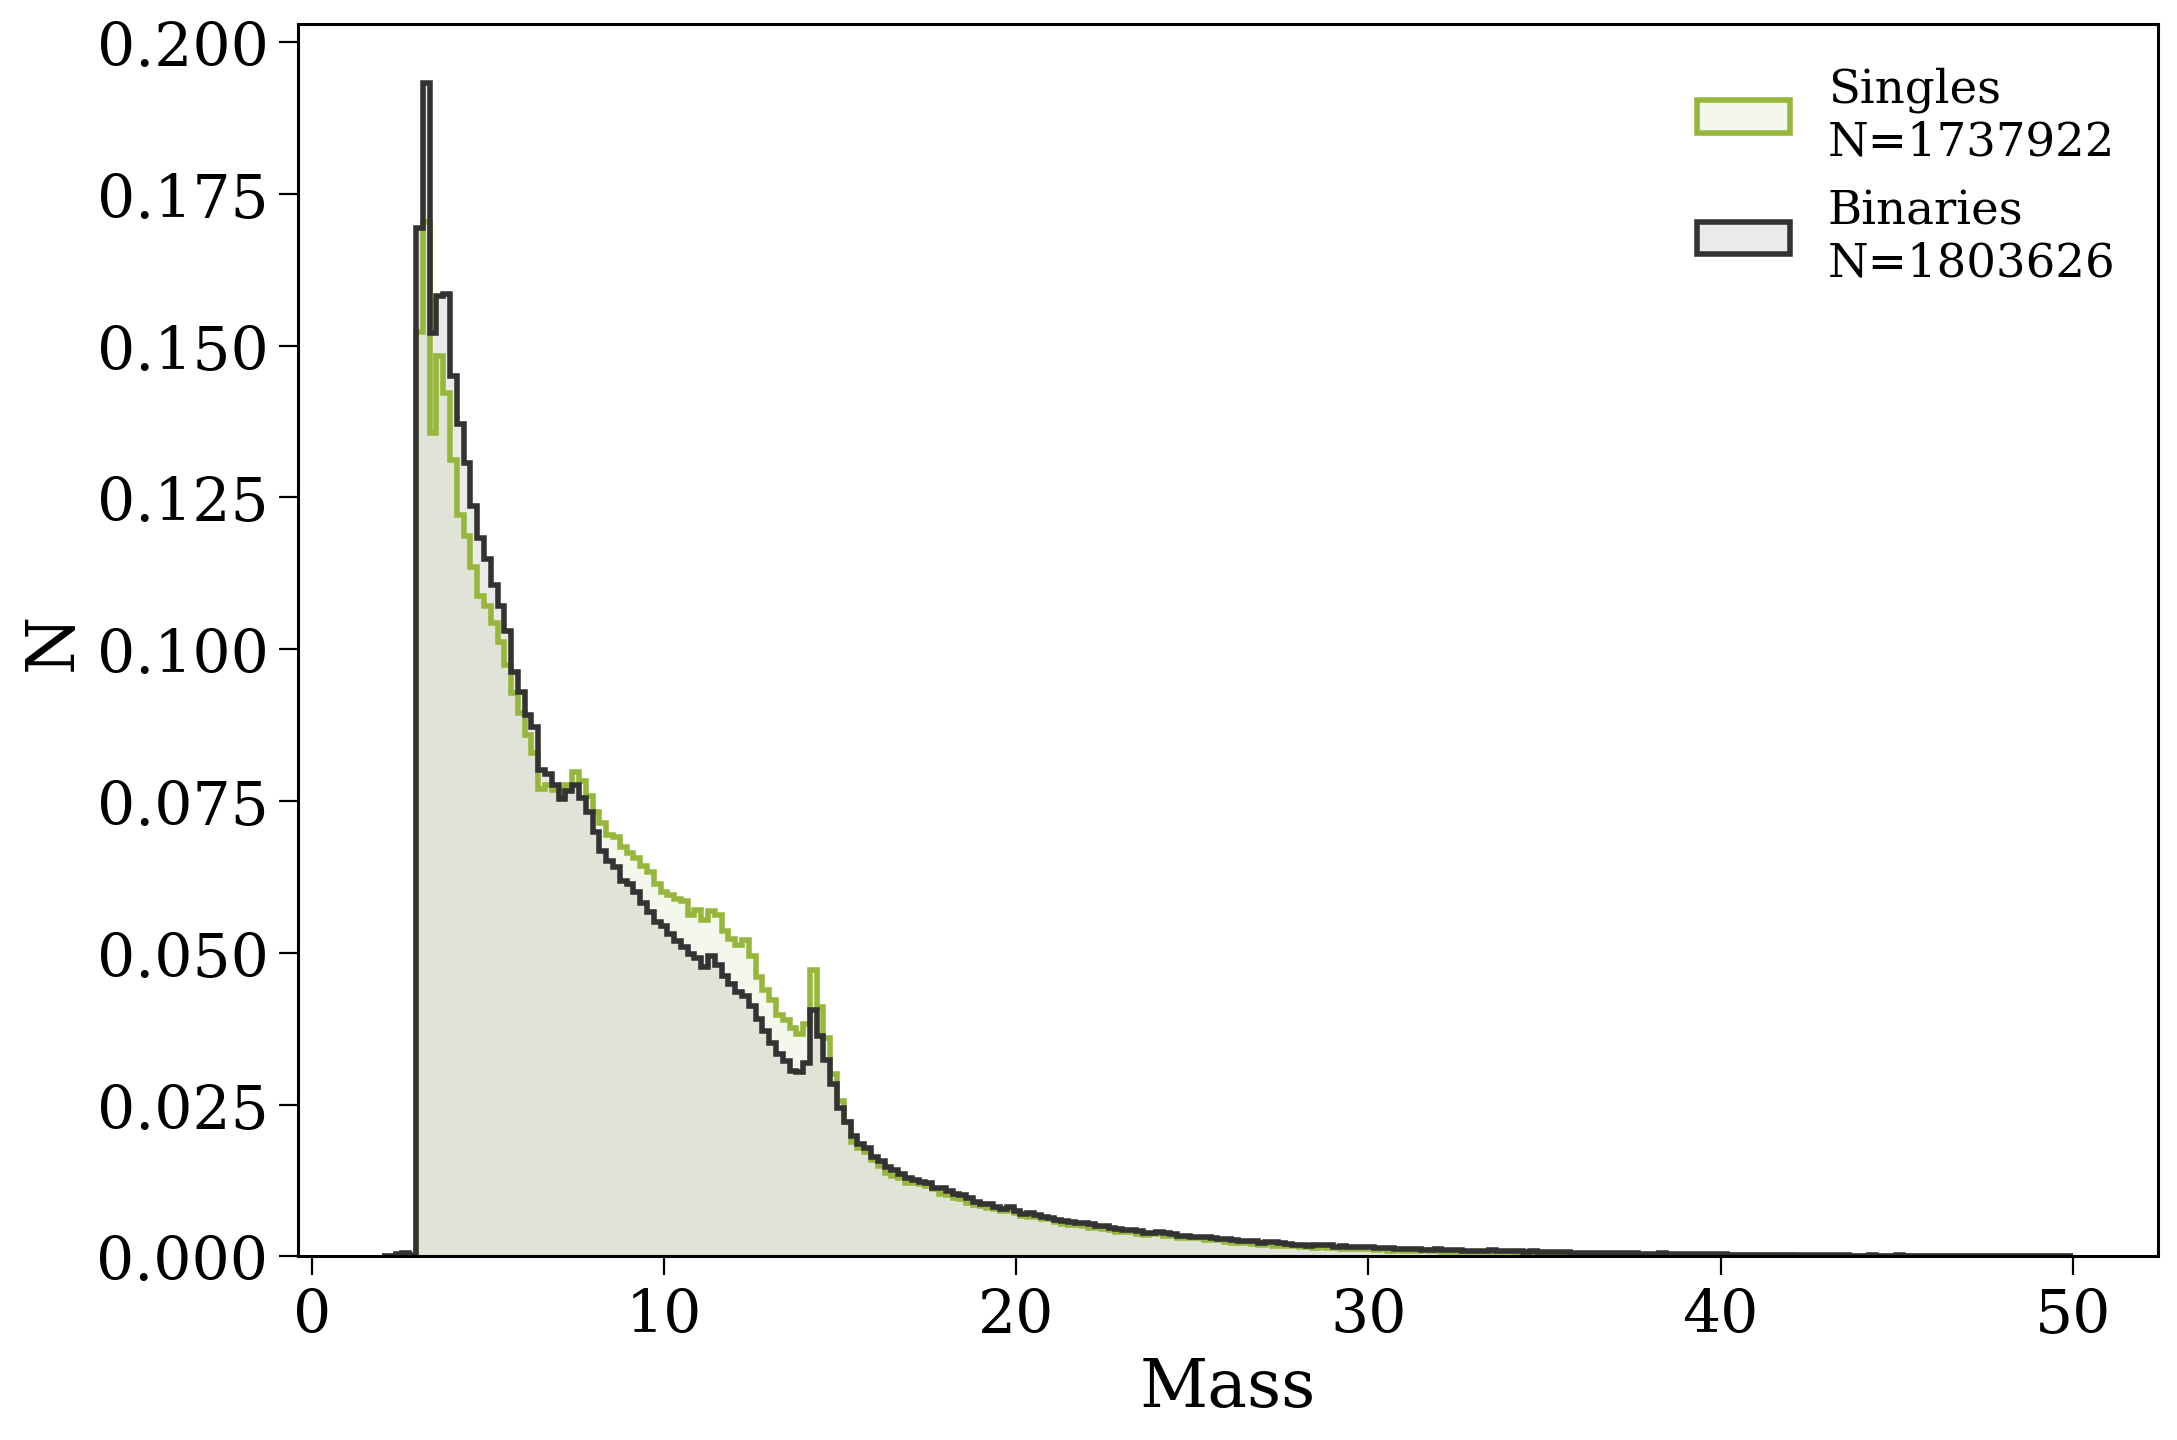

(<Figure size 1200x800 with 1 Axes>, <Axes: xlabel='Mass', ylabel='N'>)

In [9]:
plotting.plot_mass_histogram(
    pops, data, bins=np.linspace(2, 50, 250), co_type="BH", xlabel="Mass", ylabel="N", density=True, alpha=0.1
)

# Kinematics

## Scale heights

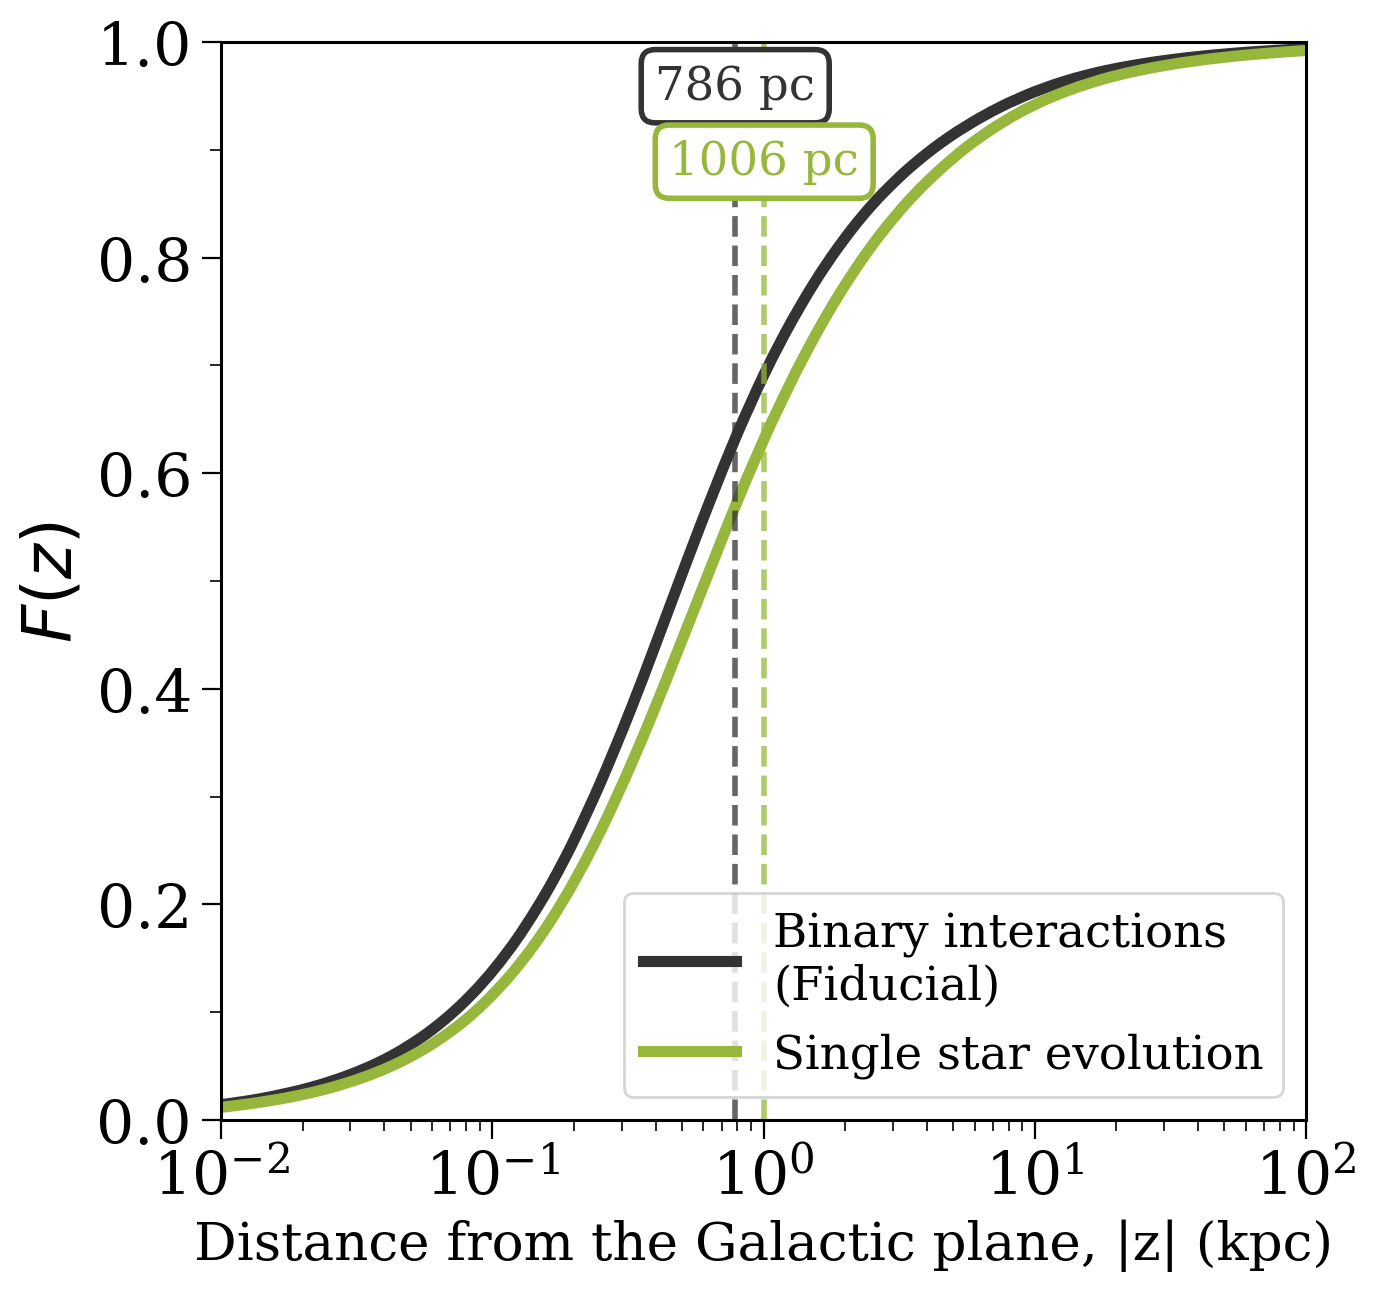

In [12]:
reload(plotting)

fig, ax = plt.subplots(figsize=(7, 7))

for z, label, colour, loc in zip(
    [data["Binaries"]["pos"]["BH"][:, 2][~data["Binaries"]["escaped"]["BH"]],
     data["Singles"]["pos"]["BH"][:, 2][~data["Singles"]["escaped"]["BH"]]],
    ["Binary interactions\n(Fiducial)", "Single star evolution", "Singles (split)"],
    ["#333", "#96B73B", "blue"],
    [0.98, 0.98 - 0.07, 0.98-0.2]
):
    scale_height, scale_height_err, _, _ = plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1),
        scale_height_loc=loc
    )

# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_singles.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Vertical position histograms

Singles 0.36607749352249935
Binaries 0.5554059450783339
Singles 0.271198201389326
Binaries 0.46743066909734937


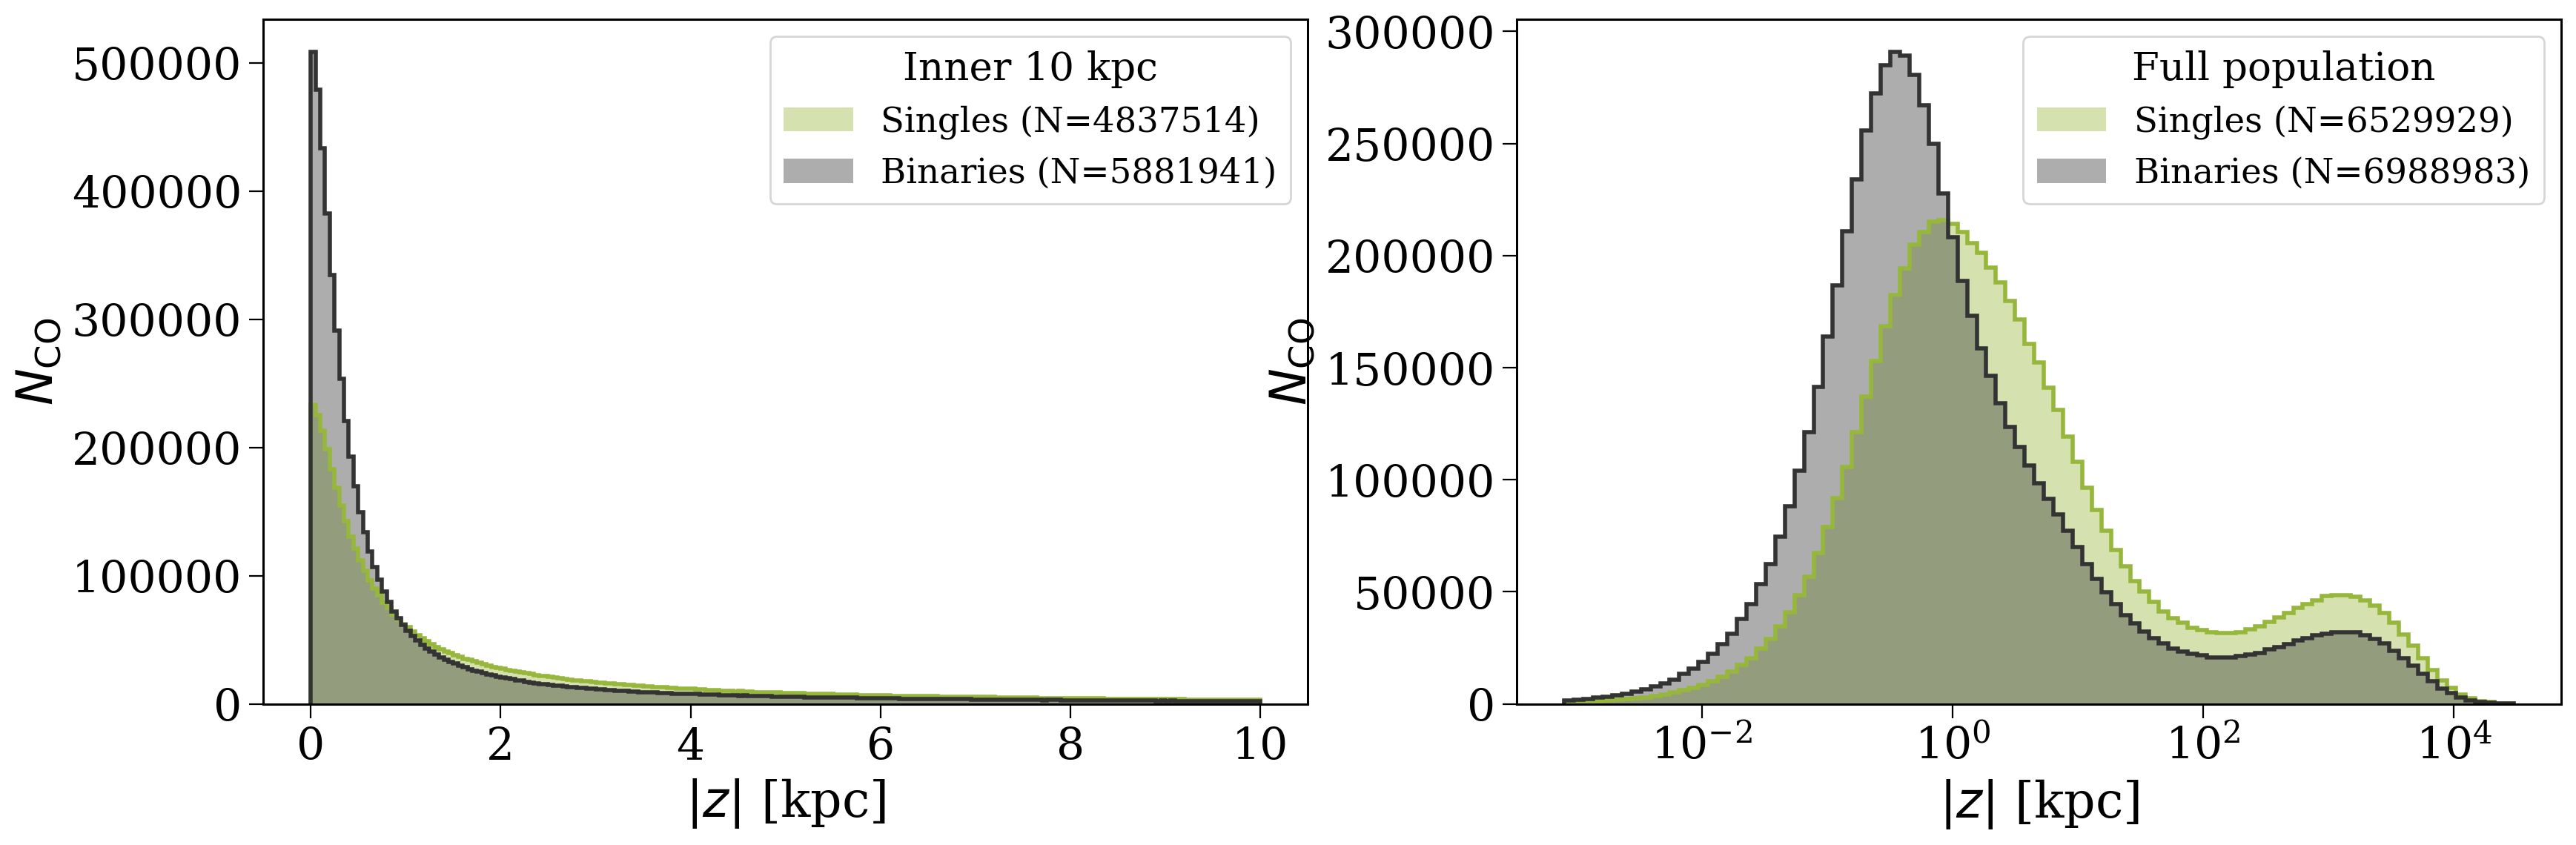

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 10, 201), np.geomspace(8e-4, 3e4, 100)]
labels = ['Inner 10 kpc', 'Full population']

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    for pop in pops:
        co_pos = data[pop.label]["pos"]["CO"]

        mask = np.abs(co_pos[:, 2]) < bins[-1]

        print(pop.label, (abs(co_pos[:, 2]) < 0.5).sum() / mask.sum())

        ax.hist(np.abs(co_pos[:, 2]), bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(np.abs(co_pos[:, 2]), bins=bins, alpha=0.4, color=pop.colour,
                label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$|z|$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

## Density distributions

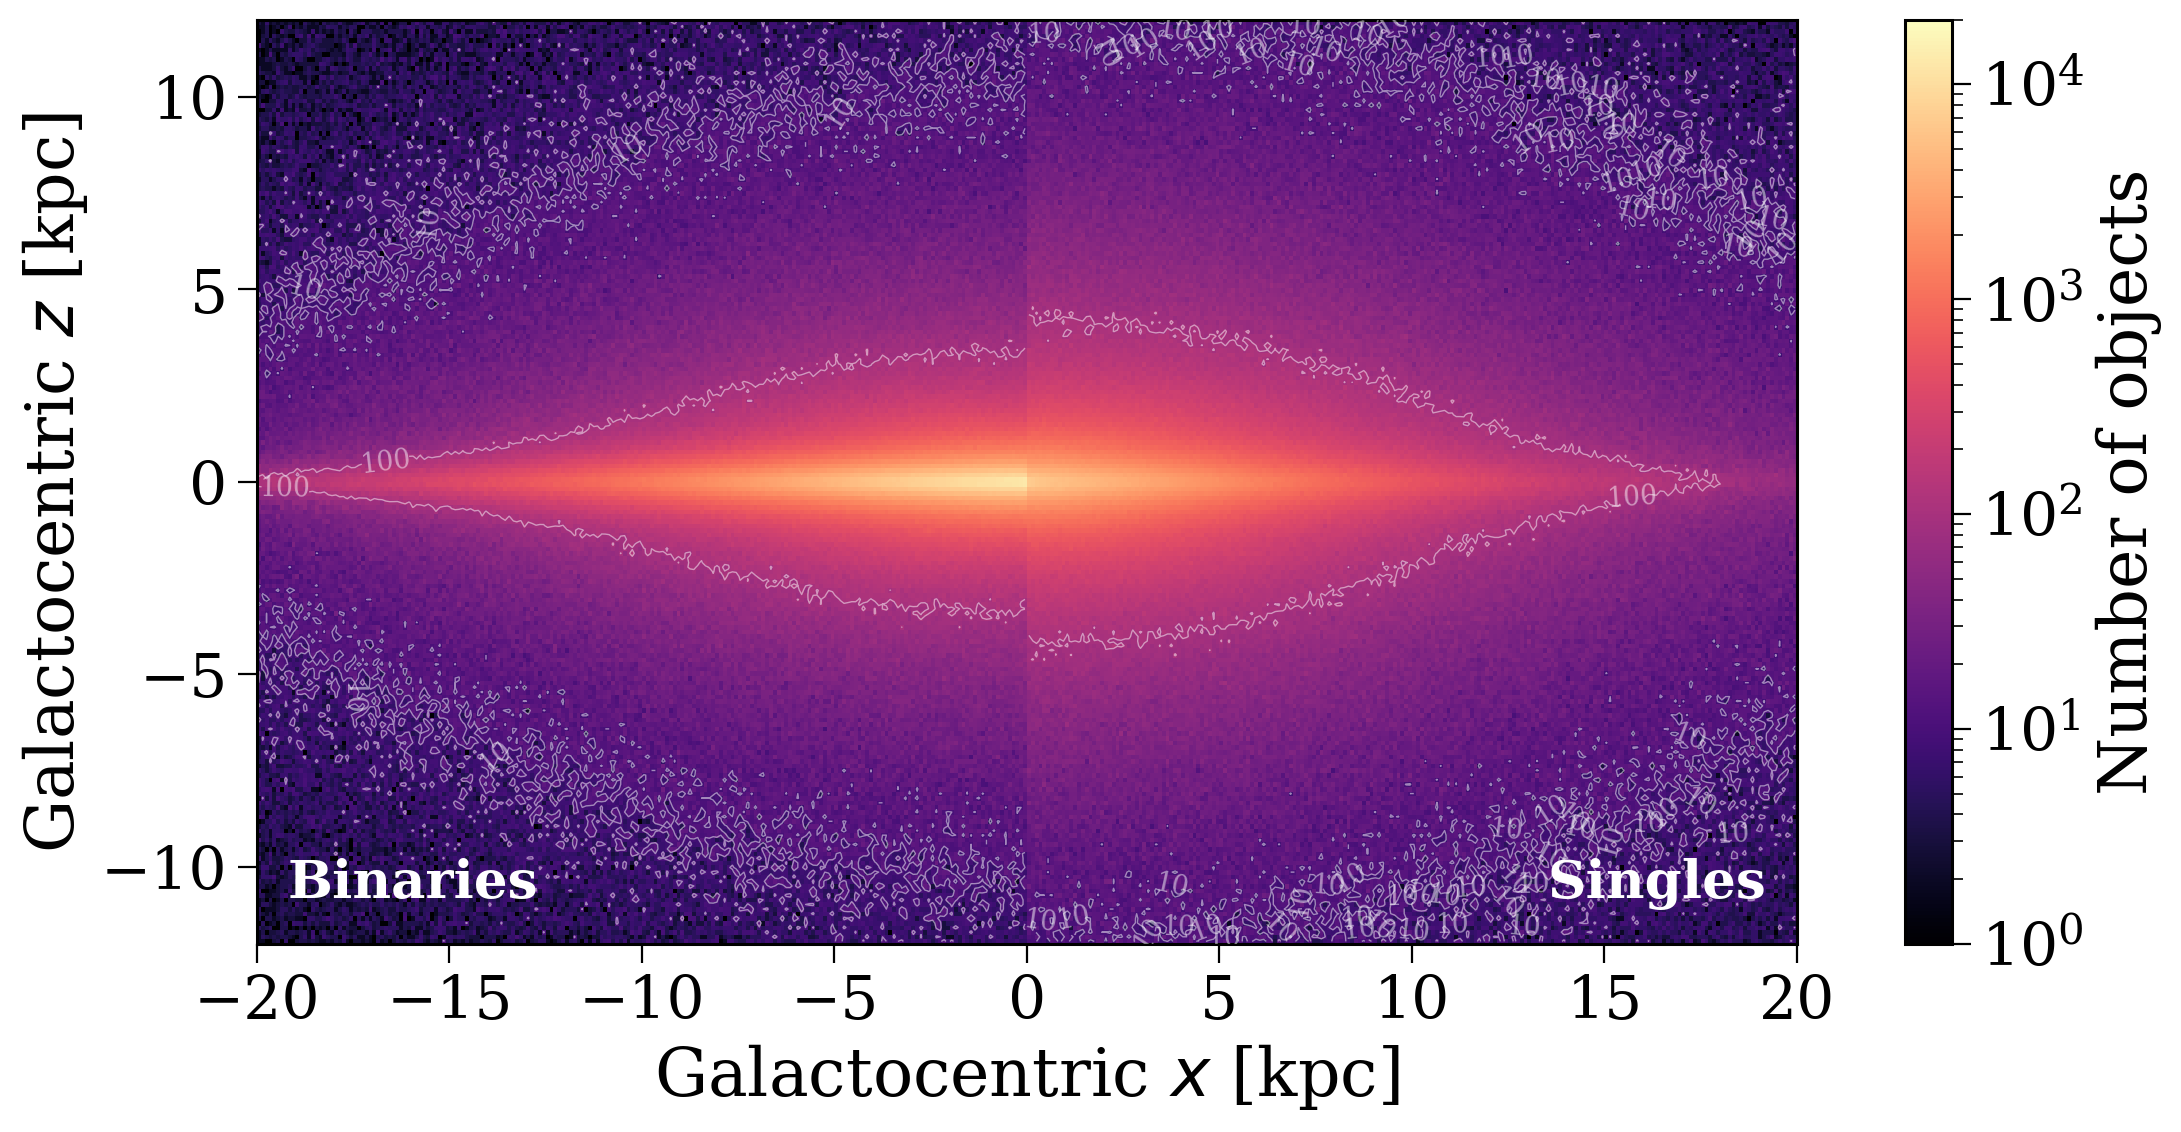

(<Figure size 1400x600 with 2 Axes>,
 <Axes: xlabel='Galactocentric $x$ [kpc]', ylabel='Galactocentric $z$ [kpc]'>)

In [14]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[data["Singles"]["pos"]["CO"][:, 0], data["Binaries"]["pos"]["CO"][:, 0]],
    zs=[data["Singles"]["pos"]["CO"][:, 2], data["Binaries"]["pos"]["CO"][:, 2]],
    labels=["Binaries", "Singles"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=0.0,
    contours=[10, 100],
    apply_smoothing=True,
)

# BELOW HERE REQUIRES FULL DATA

## It's mergers right?

Mergers can both increase and decrease the total number of COs formed from a given total stellar mass since:

1. A merger of two stars that could both have become COs decreases your CO count by 1
2. A merger of two low mass stars that couldn't become COs without merging increases your count by 1

Arguably from the IMF, the latter should be more common and so binaries should make many more COs

In [16]:
# takes about 5 minutes to run
binaries_full_data = helpers.load_distributed_pop(
    base_path='/mnt/ceph/users/twagg/underworld/sims/',
    sim_name="fiducial",
    parts=5,
    label="Binaries",
    colour="#333"
)

Loading distributed population Binaries from 5 parts
   loaded part 1/5 of Binaries with 165709 binaries
   loaded part 2/5 of Binaries with 165988 binaries
   loaded part 3/5 of Binaries with 165381 binaries
   loaded part 4/5 of Binaries with 165802 binaries
   loaded part 5/5 of Binaries with 165547 binaries


In [17]:
# takes about 5 minutes to run
singles_full_data = helpers.load_distributed_pop(
    base_path='/mnt/ceph/users/twagg/underworld/sims/',
    sim_name="singles",
    parts=5,
    label="Singles",
    colour=colours[1]
)

Loading distributed population Singles from 5 parts
   loaded part 1/5 of Singles with 191124 binaries
   loaded part 2/5 of Singles with 191740 binaries
   loaded part 3/5 of Singles with 191454 binaries
   loaded part 4/5 of Singles with 192122 binaries


cogsworth warning: You have not provided any binary stellar evolution (BSE) settings. You must provide either `BSE_settings` or an `ini_file` in order to perform stellar evolution with COSMIC. You may set `use_default_BSE_settings=True` to use the default settings listed in cogsworth, but do so at your own risk and be sure to understand the choices that you have made.
Run `cogsworth.utils.list_BSE_defaults()` to see these.


   loaded part 5/5 of Singles with 191645 binaries


In [18]:
stellar_merger_nums = binaries_full_data.bpp[(
    (
        (binaries_full_data.bpp['kstar_1'] == 15) & (binaries_full_data.bpp["kstar_2"] < 13)
    ) | (
        (binaries_full_data.bpp['kstar_2'] == 15) & (binaries_full_data.bpp["kstar_1"] < 13)
    )
)].drop_duplicates(subset="bin_num", keep="first")["bin_num"]

ends_as_bh = binaries_full_data.final_bpp["bin_num"][(binaries_full_data.final_bpp["kstar_1"] == 14) | (binaries_full_data.final_bpp["kstar_2"] == 14)]
merger_bh_nums = np.intersect1d(stellar_merger_nums, ends_as_bh)

In [19]:
ever_bhbh = binaries_full_data.bpp[((binaries_full_data.bpp["kstar_1"] == 14) & (binaries_full_data.bpp["kstar_2"] == 14) & (binaries_full_data.bpp["sep"] > 0.0))]["bin_num"]

In [20]:
merger_bh = binaries_full_data.final_bpp["bin_num"][(binaries_full_data.final_bpp["kstar_1"] == 15) & (binaries_full_data.final_bpp["kstar_2"] == 14)]

In [21]:
(data["Binaries"]["sep"]["BH"] == 0.0).sum() / data["Binaries"]["n_BH"]

np.float64(0.32896565030666003)

In [22]:
len(merger_bh_nums) / ((binaries_full_data.final_bpp["kstar_1"] == 14).sum() + (binaries_full_data.final_bpp["kstar_2"] == 14).sum())

np.float64(0.27560296179824545)

In [23]:
merger_bh_inits = binaries_full_data.initC.loc[merger_bh_nums]

In [24]:
min_bh_mass_df = pd.read_hdf("~/ceph/underworld/cosmic_bh_crit.h5", key="min_bh_mass")

# add a row with 0.03 and 150
if max(min_bh_mass_df["metallicity"]) < 0.03:
    min_bh_mass_df = pd.concat([pd.DataFrame({"metallicity": [0.03], "mass_1": [150]}), min_bh_mass_df], ignore_index=True)

min_bh_mass = interp1d(min_bh_mass_df["metallicity"], min_bh_mass_df["mass_1"])

In [25]:
LIM = min_bh_mass(merger_bh_inits["metallicity"].values)
high_mass_mergers = (merger_bh_inits["mass_1"] >= LIM) & (merger_bh_inits["mass_2"] >= LIM)
low_mass_mergers = (merger_bh_inits["mass_1"] < LIM) & (merger_bh_inits["mass_2"] < LIM)

print(f"Total mergers: {len(merger_bh_inits)}")
print(f'  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / len(merger_bh_inits):.2%} of mergers) ({high_mass_mergers.sum() / ((binaries_full_data.final_bpp["kstar_1"] == 14).sum() + (binaries_full_data.final_bpp["kstar_2"] == 14).sum()):.2%} of BHs)')
print(f'  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / len(merger_bh_inits):.2%} of mergers) ({low_mass_mergers.sum() / ((binaries_full_data.final_bpp["kstar_1"] == 14).sum() + (binaries_full_data.final_bpp["kstar_2"] == 14).sum()):.2%} of BHs)')

Total mergers: 72916
  High mass mergers: 9500 (13.03% of mergers) (3.59% of BHs)
  Low mass mergers: 22203 (30.45% of mergers) (8.39% of BHs)


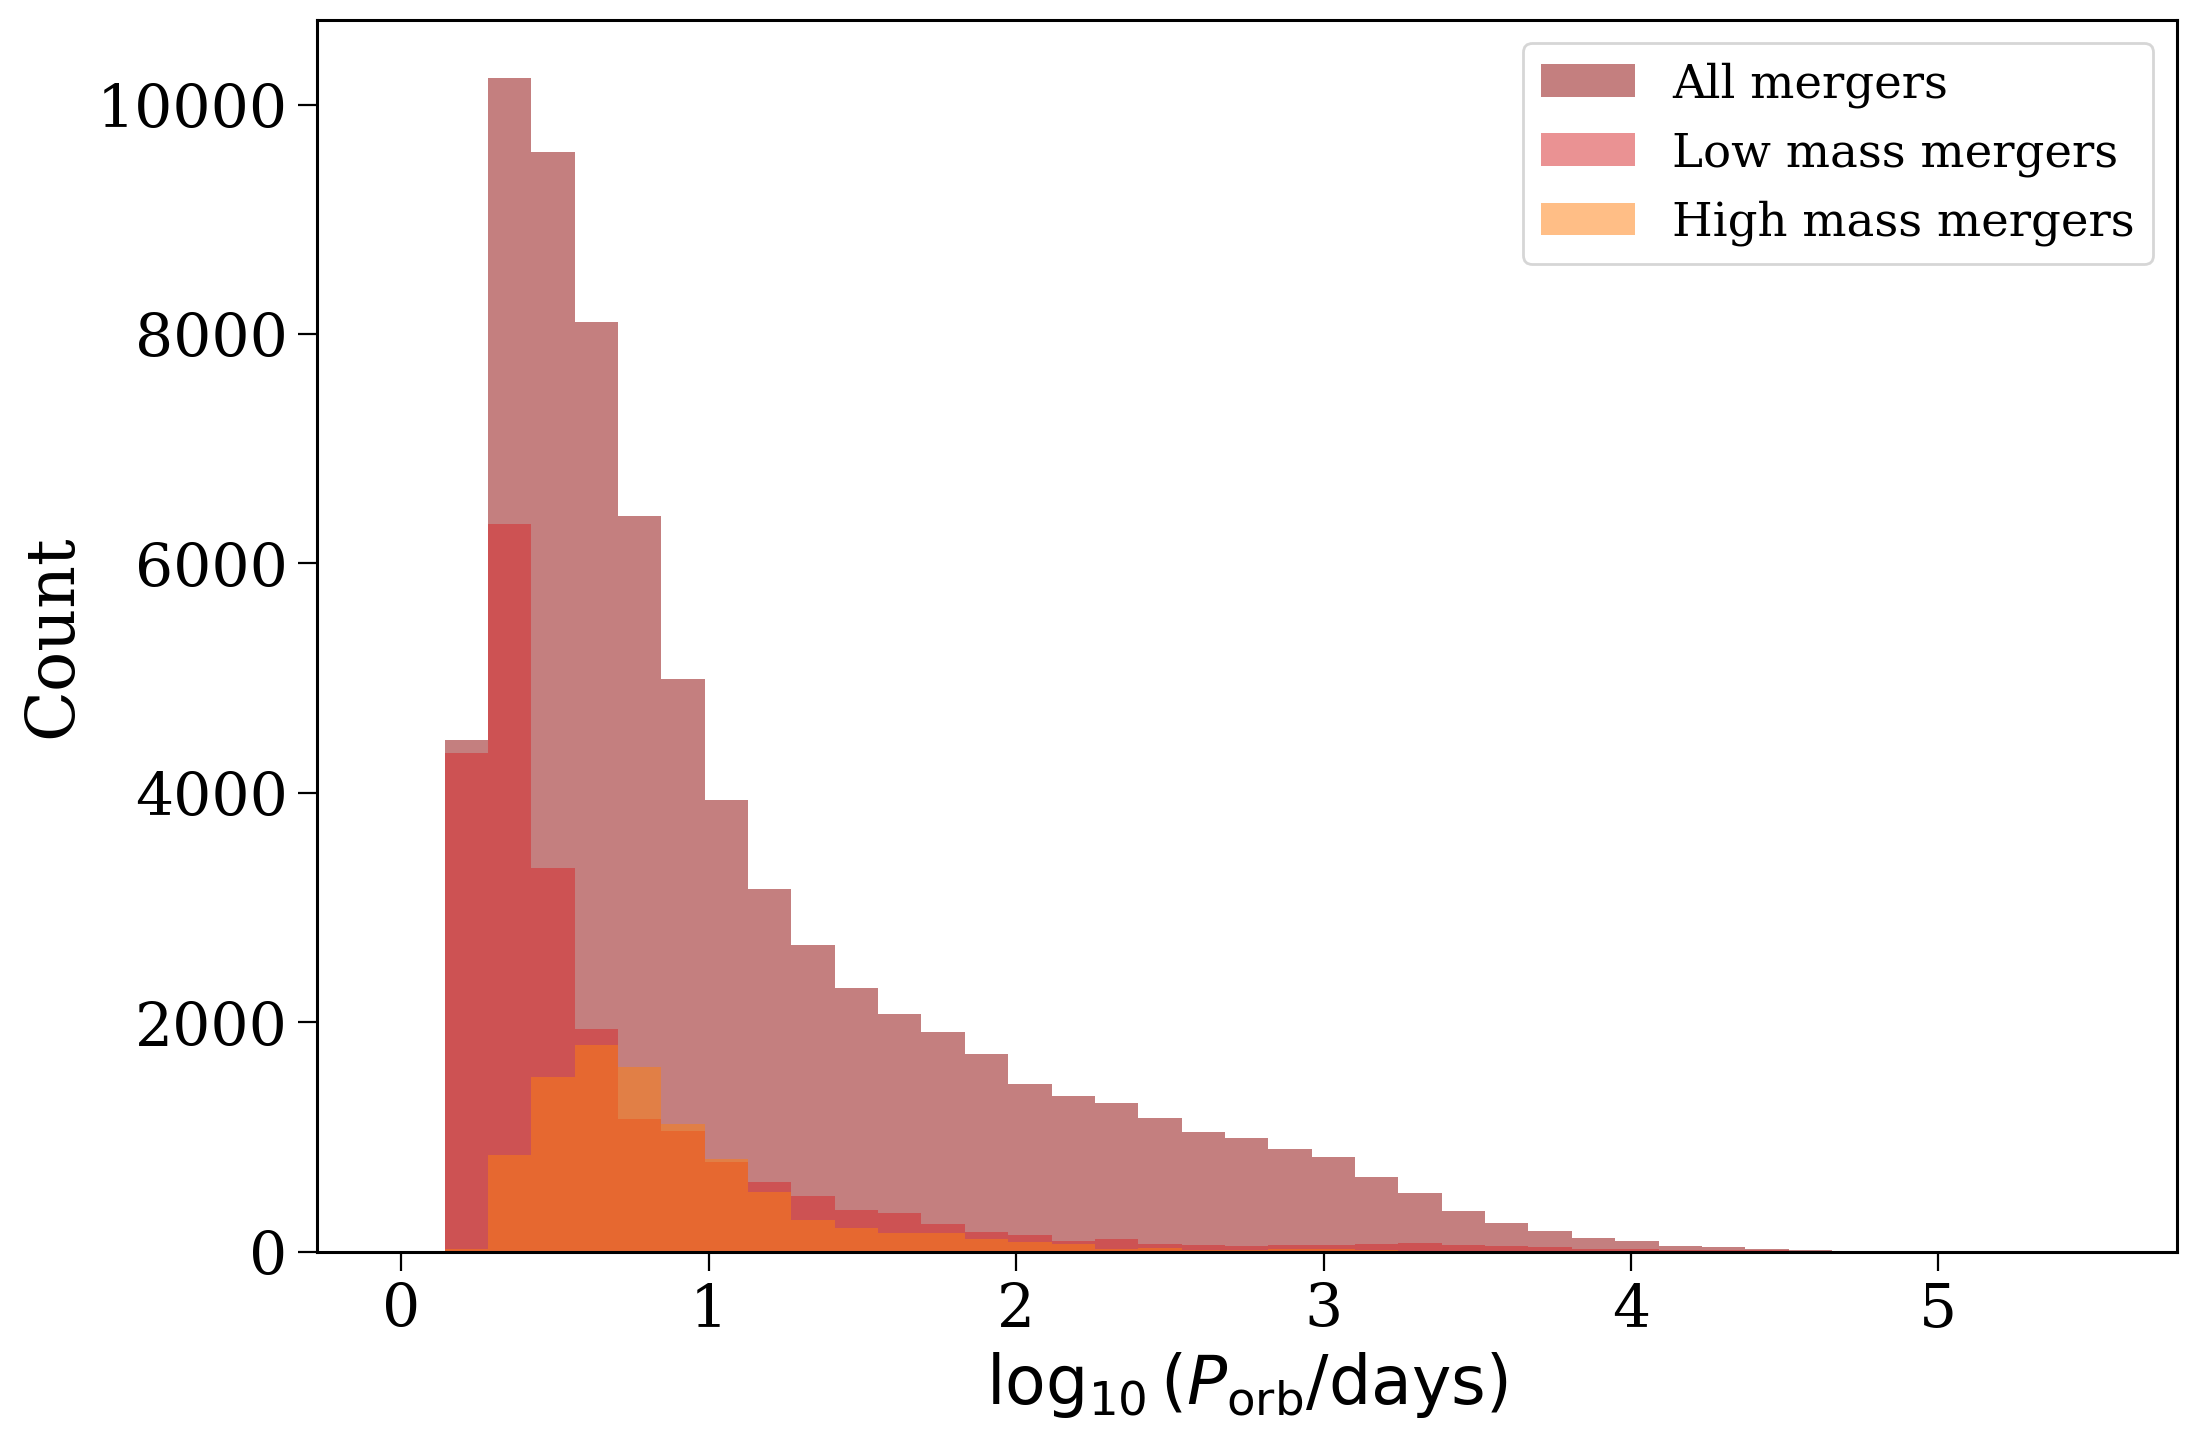

In [26]:
fig, ax = plt.subplots()

bins = np.linspace(0, 5.5, 40)

# ax.hist(np.log10(binaries.initC["porb"]), bins=bins, alpha=0.5, label="All binaries", color="black")
ax.hist(np.log10(merger_bh_inits["porb"]), bins=bins, alpha=0.5, label="All mergers", color="darkred")
ax.hist(np.log10(merger_bh_inits["porb"][low_mass_mergers]), bins=bins, alpha=0.5, label="Low mass mergers", color="tab:red")
ax.hist(np.log10(merger_bh_inits["porb"][high_mass_mergers]), bins=bins, alpha=0.5, label="High mass mergers", color="tab:orange")

ax.set(
    xlabel=r"$\log_{10}(P_{\rm orb} / \mathrm{days})$",
    ylabel="Count",
)
ax.legend()
plt.show()

## Kick distributions

In [28]:
bh_kick_stats = {
    pop.label: helpers.get_kick_stats(pop) for pop in [singles_full_data, binaries_full_data]
}

In [27]:
bh_kick_stats = {}

for pop in [singles_full_data, binaries_full_data]:
    primary_bh_rows = pop.bpp[pop.bpp["row_num"].isin(pop.bpp[pop.bpp["evol_type"] == 15]["row_num"] + 1) & (pop.bpp["kstar_1"] == 14)]
    primary_bh_explosion_bin_nums = primary_bh_rows["bin_num"].values
    primary_bh_mass = primary_bh_rows["mass_1"].values
    primary_companion_mass = primary_bh_rows["mass_2"].values

    primary_pre_sn = pop.bpp.loc[primary_bh_explosion_bin_nums][pop.bpp.loc[primary_bh_explosion_bin_nums, "kstar_1"] < 13].drop_duplicates(subset="bin_num", keep="last")
    primary_sep = primary_pre_sn["sep"].values
    primary_progenitor_mass = primary_pre_sn["mass_1"].values

    secondary_bh_rows = pop.bpp[pop.bpp["row_num"].isin(pop.bpp[pop.bpp["evol_type"] == 16]["row_num"] + 1) & (pop.bpp["kstar_2"] == 14)]
    secondary_bh_explosion_bin_nums = secondary_bh_rows["bin_num"].values
    secondary_bh_mass = secondary_bh_rows["mass_2"].values
    secondary_companion_mass = secondary_bh_rows["mass_1"].values
    secondary_pre_sn = pop.bpp.loc[secondary_bh_explosion_bin_nums][pop.bpp.loc[secondary_bh_explosion_bin_nums, "kstar_2"] < 13].drop_duplicates(subset="bin_num", keep="last")
    secondary_sep = secondary_pre_sn["sep"].values
    secondary_progenitor_mass = secondary_pre_sn["mass_2"].values

    primary_kick_rows = pop.kick_info.loc[primary_bh_explosion_bin_nums][pop.kick_info.loc[primary_bh_explosion_bin_nums]["star"] == 1]
    primary_kicks = primary_kick_rows["natal_kick"].values
    primary_deltav = np.linalg.norm(primary_kick_rows[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]], axis=1)
    primary_disrupted = primary_kick_rows["disrupted"].values
    secondary_kicks = []
    secondary_deltav = []
    secondary_disrupted = []
    if len(secondary_bh_explosion_bin_nums) > 0:
        secondary_kick_rows = pop.kick_info.loc[secondary_bh_explosion_bin_nums][pop.kick_info.loc[secondary_bh_explosion_bin_nums]["star"] == 2]
        secondary_deltav = np.linalg.norm(secondary_kick_rows[["delta_vsysx_2", "delta_vsysy_2", "delta_vsysz_2"]], axis=1)
        secondary_kicks = secondary_kick_rows["natal_kick"].values
        secondary_disrupted = secondary_kick_rows["disrupted"].values

    kick_stat_dict = {}
    kick_stat_dict["natal_kick"] = np.concatenate([primary_kicks, secondary_kicks])
    kick_stat_dict["delta_v"] = np.concatenate([primary_deltav, secondary_deltav])
    kick_stat_dict["disrupted"] = np.concatenate([primary_disrupted, secondary_disrupted])
    kick_stat_dict["bh_mass"] = np.concatenate([primary_bh_mass, secondary_bh_mass])
    kick_stat_dict["companion_mass"] = np.concatenate([primary_companion_mass, secondary_companion_mass])
    kick_stat_dict["separation_at_sn"] = np.concatenate([primary_sep, secondary_sep])
    kick_stat_dict["progenitor_mass"] = np.concatenate([primary_progenitor_mass, secondary_progenitor_mass])

    kick_stat_df = pd.DataFrame(kick_stat_dict)
    bh_kick_stats[pop.label] = kick_stat_df

In [31]:
from astropy.constants import G
import astropy.units as u

In [32]:
for key in bh_kick_stats:
    bh_kick_stats[key]["m_binary_pre_sn"] = bh_kick_stats[key]["progenitor_mass"] + bh_kick_stats[key]["companion_mass"]
    bh_kick_stats[key]["m_binary"] = bh_kick_stats[key]["bh_mass"] / bh_kick_stats[key]["progenitor_mass"]
    bh_kick_stats[key]["delta_m1"] = bh_kick_stats[key]["progenitor_mass"] - bh_kick_stats[key]["bh_mass"]
    bh_kick_stats[key]["v_orb_pre_sn"] = np.sqrt(G * bh_kick_stats[key]["m_binary_pre_sn"].values * u.Msun / (bh_kick_stats[key]["separation_at_sn"].values * u.Rsun)).to(u.km/u.s).value

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [33]:
bh_kick_stats["Binaries"]

,natal_kick,delta_v,disrupted,bh_mass,companion_mass,separation_at_sn,progenitor_mass,progenitor_type,is_primary,bin_num,m_binary_pre_sn,m_binary,delta_m1,v_orb_pre_sn
0,21.512589,5.897582,0.0,10.423318,36.745330,5171.327842,12.808012,8,True,4,49.553342,0.813812,2.384694,42.754345
1,178.655252,180.201657,1.0,3.343047,2.303048,3251.599002,7.702546,8,True,82,10.005594,0.434018,4.359499,24.228011
2,5.644283,1.809291,0.0,13.777580,29.745694,27023.216909,14.446141,8,True,134,44.191835,0.953720,0.668561,17.662302
3,160.786568,160.786568,1.0,3.137284,0.000000,0.000000,7.454335,8,True,147,7.454335,0.420867,4.317051,inf
4,0.000000,1.019795,0.0,20.748665,59.507946,312.051871,21.248665,7,True,159,80.756611,0.976469,0.500000,222.187930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265066,31.228718,31.228718,1.0,10.358639,0.000000,0.000000,12.756198,8,False,1589086,12.756198,0.812048,2.397559,inf
265067,347.804254,347.804254,1.0,8.525480,1.899811,-1.000000,16.814931,5,False,1589088,18.714742,0.507018,8.289450,NaN
265068,986.521177,986.521177,1.0,3.809931,0.000000,0.000000,15.885248,5,False,1589101,15.885248,0.239841,12.075317,inf
265069,25.619735,25.619735,1.0,12.952785,4.103603,-1.000000,14.115339,8,False,1589105,18.218942,0.917639,1.162553,NaN


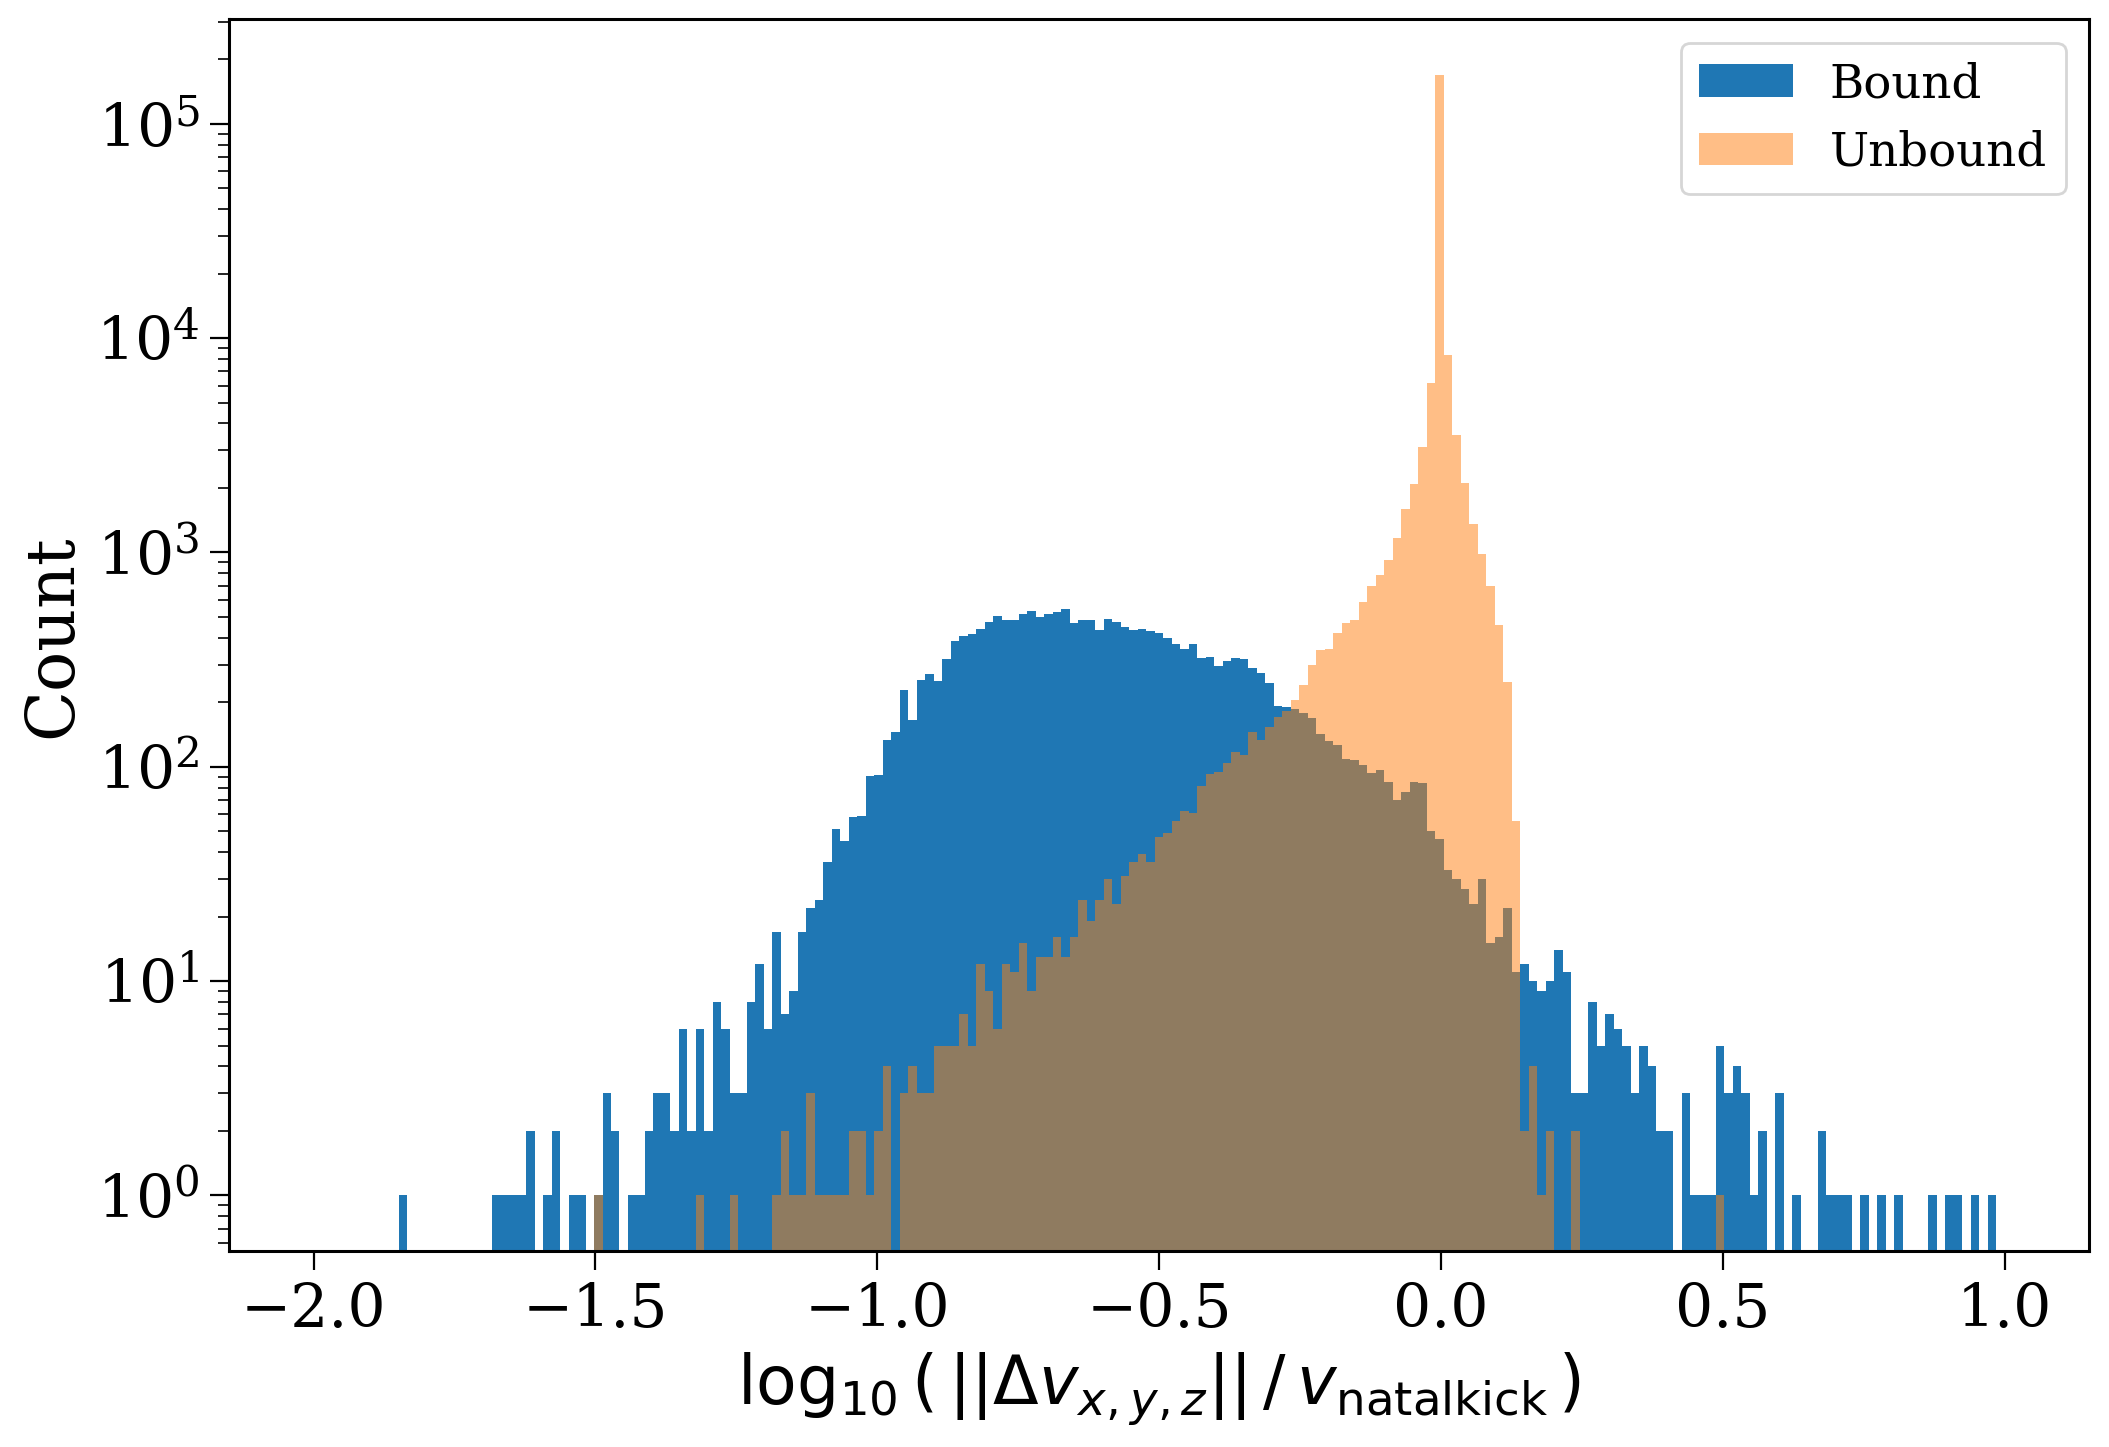

In [34]:
ratio = bh_kick_stats["Binaries"]["delta_v"] / bh_kick_stats["Binaries"]["natal_kick"]
finite_ratio_bound = ratio[(bh_kick_stats["Binaries"]["disrupted"] == 0) & np.isfinite(ratio) & (ratio > 0)]
finite_ratio_unbound = ratio[(bh_kick_stats["Binaries"]["disrupted"] == 1) & np.isfinite(ratio) & (ratio > 0)]

bins = np.linspace(-2, 1, 200)

plt.hist(np.log10(finite_ratio_bound), bins=bins, label="Bound");
plt.hist(np.log10(finite_ratio_unbound), bins=bins, alpha=0.5, label="Unbound");
plt.xlabel(r"$\log_{10}(\, ||\Delta v_{x,y,z}|| \,/ \,v_{\rm natal kick} \,)$")
plt.ylabel("Count")
plt.yscale("log")
plt.legend()
plt.show()

In [161]:
import matplotlib as mpl

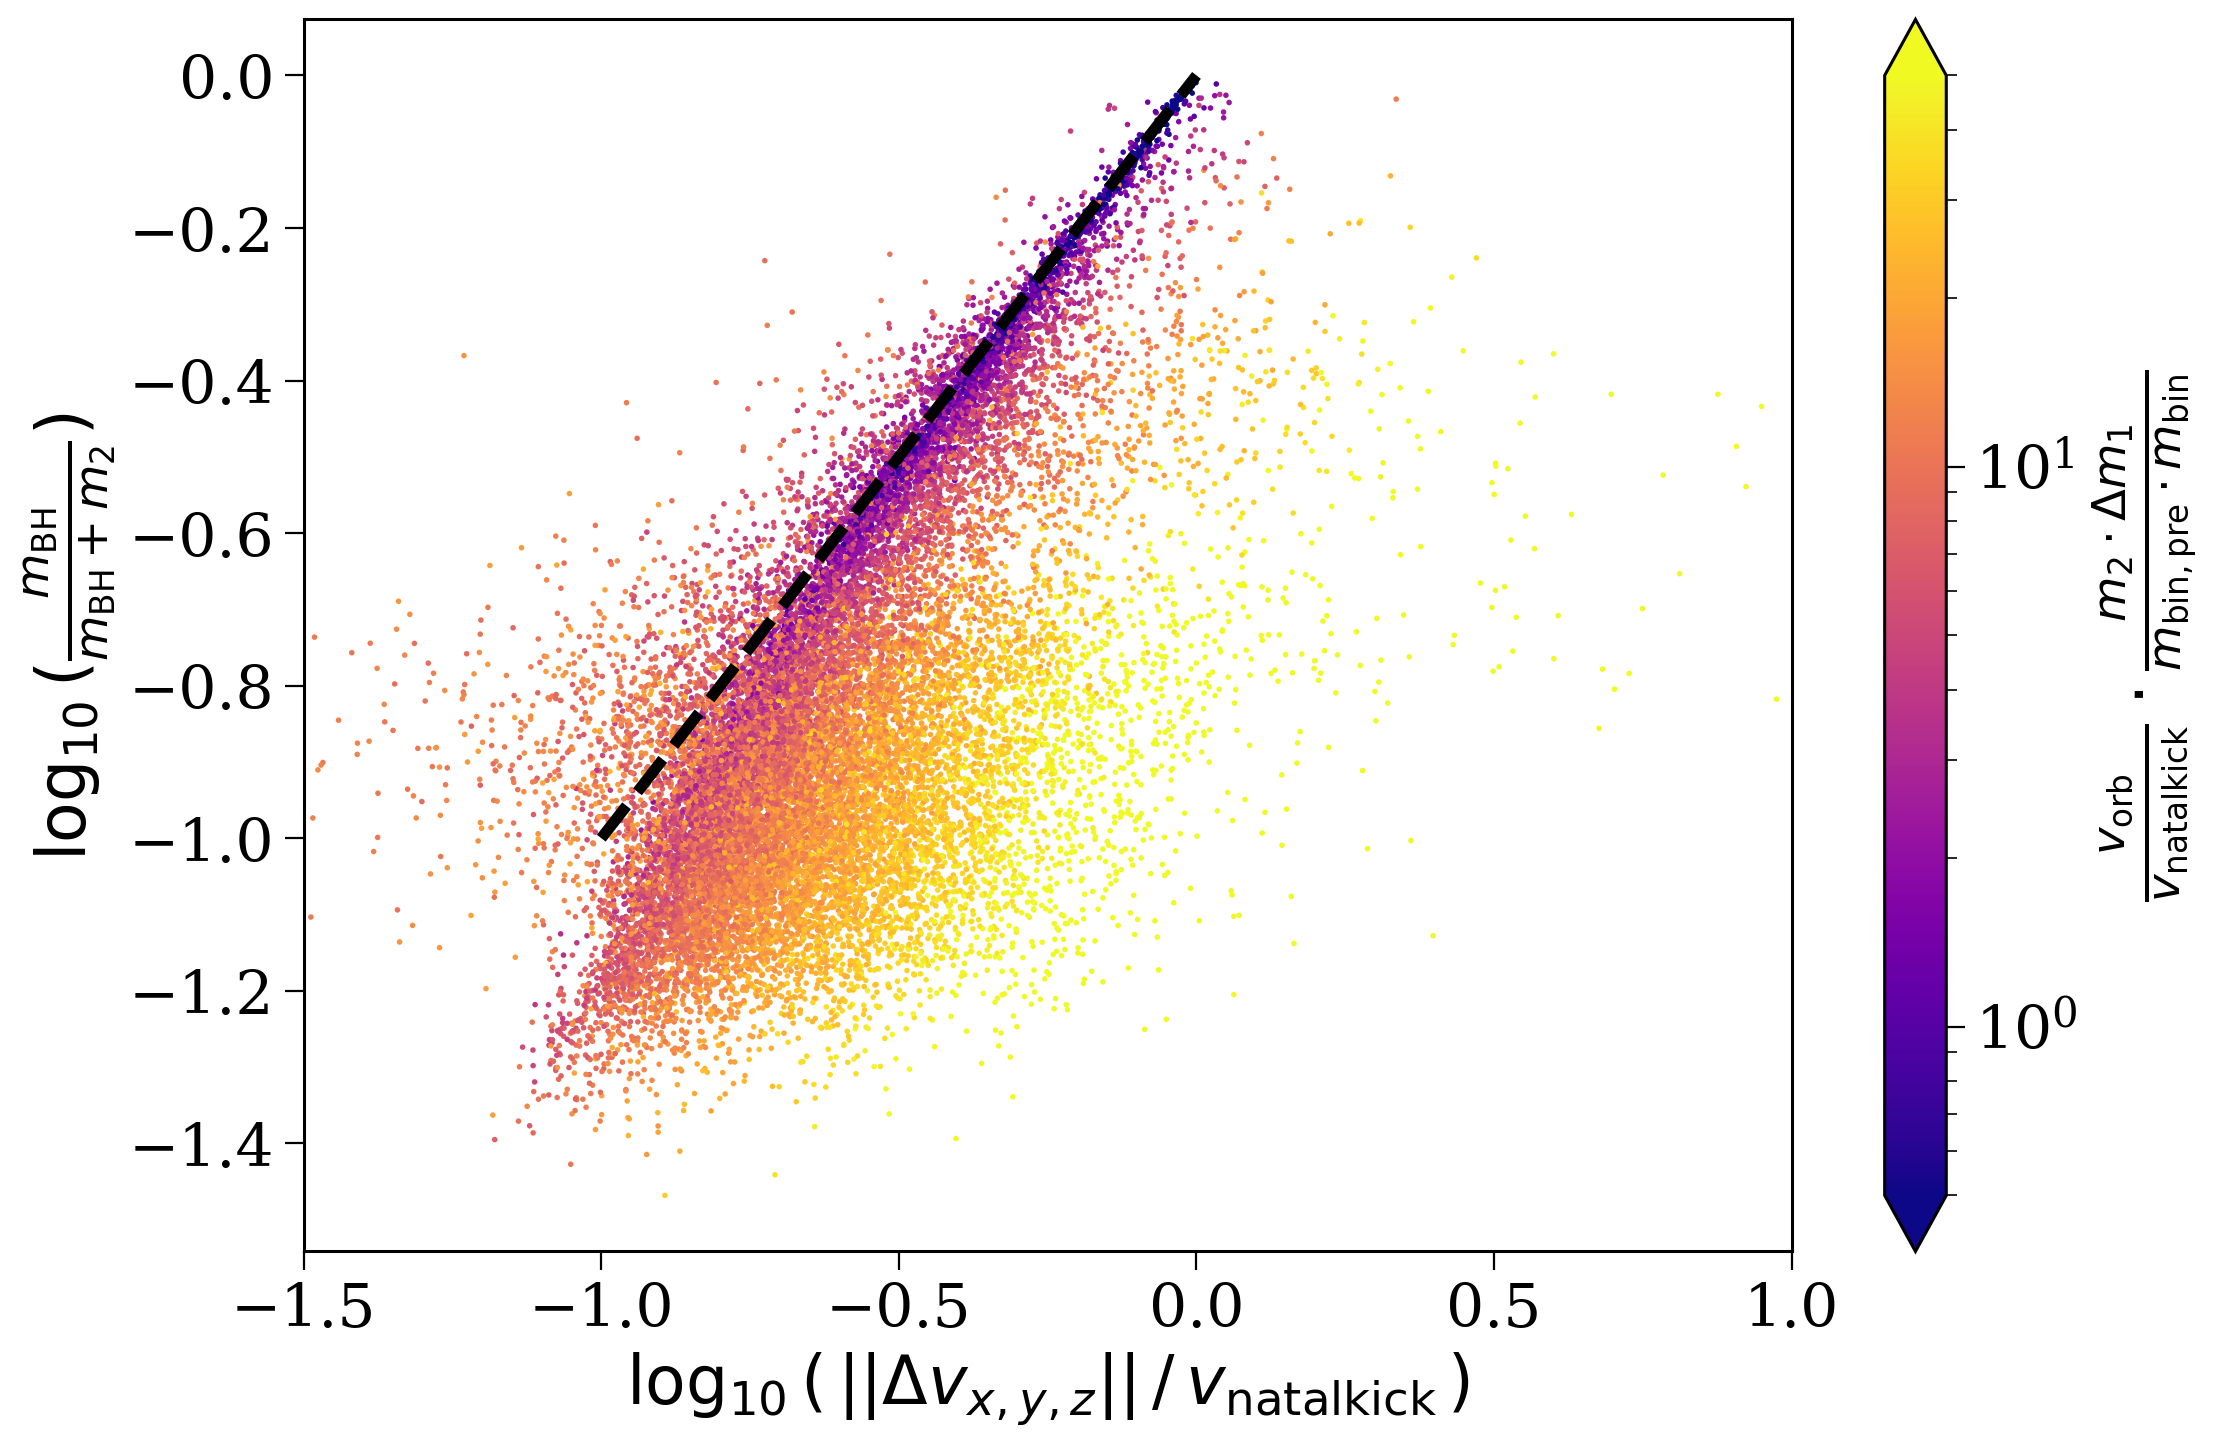

In [36]:
df = bh_kick_stats["Binaries"][(bh_kick_stats["Binaries"]["disrupted"] == 0) & np.isfinite(ratio) & (ratio > 0)]

# scatter = plt.scatter(np.log10(finite_ratio_bound), companion_mass["Binaries"][(disrupted["Binaries"] == 0) & np.isfinite(ratio) & (ratio > 0)], label="Bound", s=.1,
#                       c=np.log10(kicks["Binaries"][(disrupted["Binaries"] == 0) & np.isfinite(ratio) & (ratio > 0)]), vmin=0, vmax=2.2)
# plt.colorbar(scatter, label=r"$\log_{10}(v_{\rm natal kick} / \mathrm{km\,s^{-1}})$", extend="both")

# scatter = plt.scatter(np.log10(finite_ratio_bound), bh_mass["Binaries"][finite_bound_mask] / companion_mass["Binaries"][finite_bound_mask],
#                       label="Bound", s=.1,
#                       c=bh_mass["Binaries"][finite_bound_mask], vmin=4, vmax=15, cmap="plasma")
# plt.colorbar(scatter, label=r"$m_{\rm BH}$ [M$_\odot$]", extend="both")

natal_kick_prefactor = df["bh_mass"] / (df["bh_mass"] + df["companion_mass"])
v_cm_prefactor = df["companion_mass"] * df["delta_m1"] / (df["m_binary_pre_sn"] * df["m_binary"])

scatter = plt.scatter(np.log10(finite_ratio_bound), np.log10(natal_kick_prefactor),
            label="Bound", s=1,
            c=df["v_orb_pre_sn"] * v_cm_prefactor / df["natal_kick"], norm=mpl.colors.LogNorm(vmin=0.5, vmax=50), cmap="plasma")
plt.colorbar(scatter, label=r"$\frac{v_{\rm orb}}{v_{\rm natal kick}} \cdot \frac{m_2 \cdot \Delta m_1}{m_{\rm bin, pre} \cdot m_{\rm bin}}$", extend="both")
plt.plot([-1, 0], [-1, 0], color="black", ls='--', lw=4)

# for mBH in [4, 15]:
#     y_vals = np.linspace(0, 100, 1000)
#     x_vals = np.log10((mBH / (mBH + y_vals))**(0.5))
#     plt.plot(x_vals, y_vals, label=r"$\sqrt{m_{\rm BH} / (m_{\rm BH} + m_{\rm comp})}$", color="black", ls='--')

plt.xlabel(r"$\log_{10}(\, ||\Delta v_{x,y,z}|| \,/ \,v_{\rm natal kick} \,)$")
plt.ylabel(r"$\log_{10}(\frac{m_{\rm BH}}{m_{\rm BH} + m_2})$")
# plt.yscale("log")

plt.xlim(-1.5, 1.0)

plt.show()

# Initial conditions

## Mass

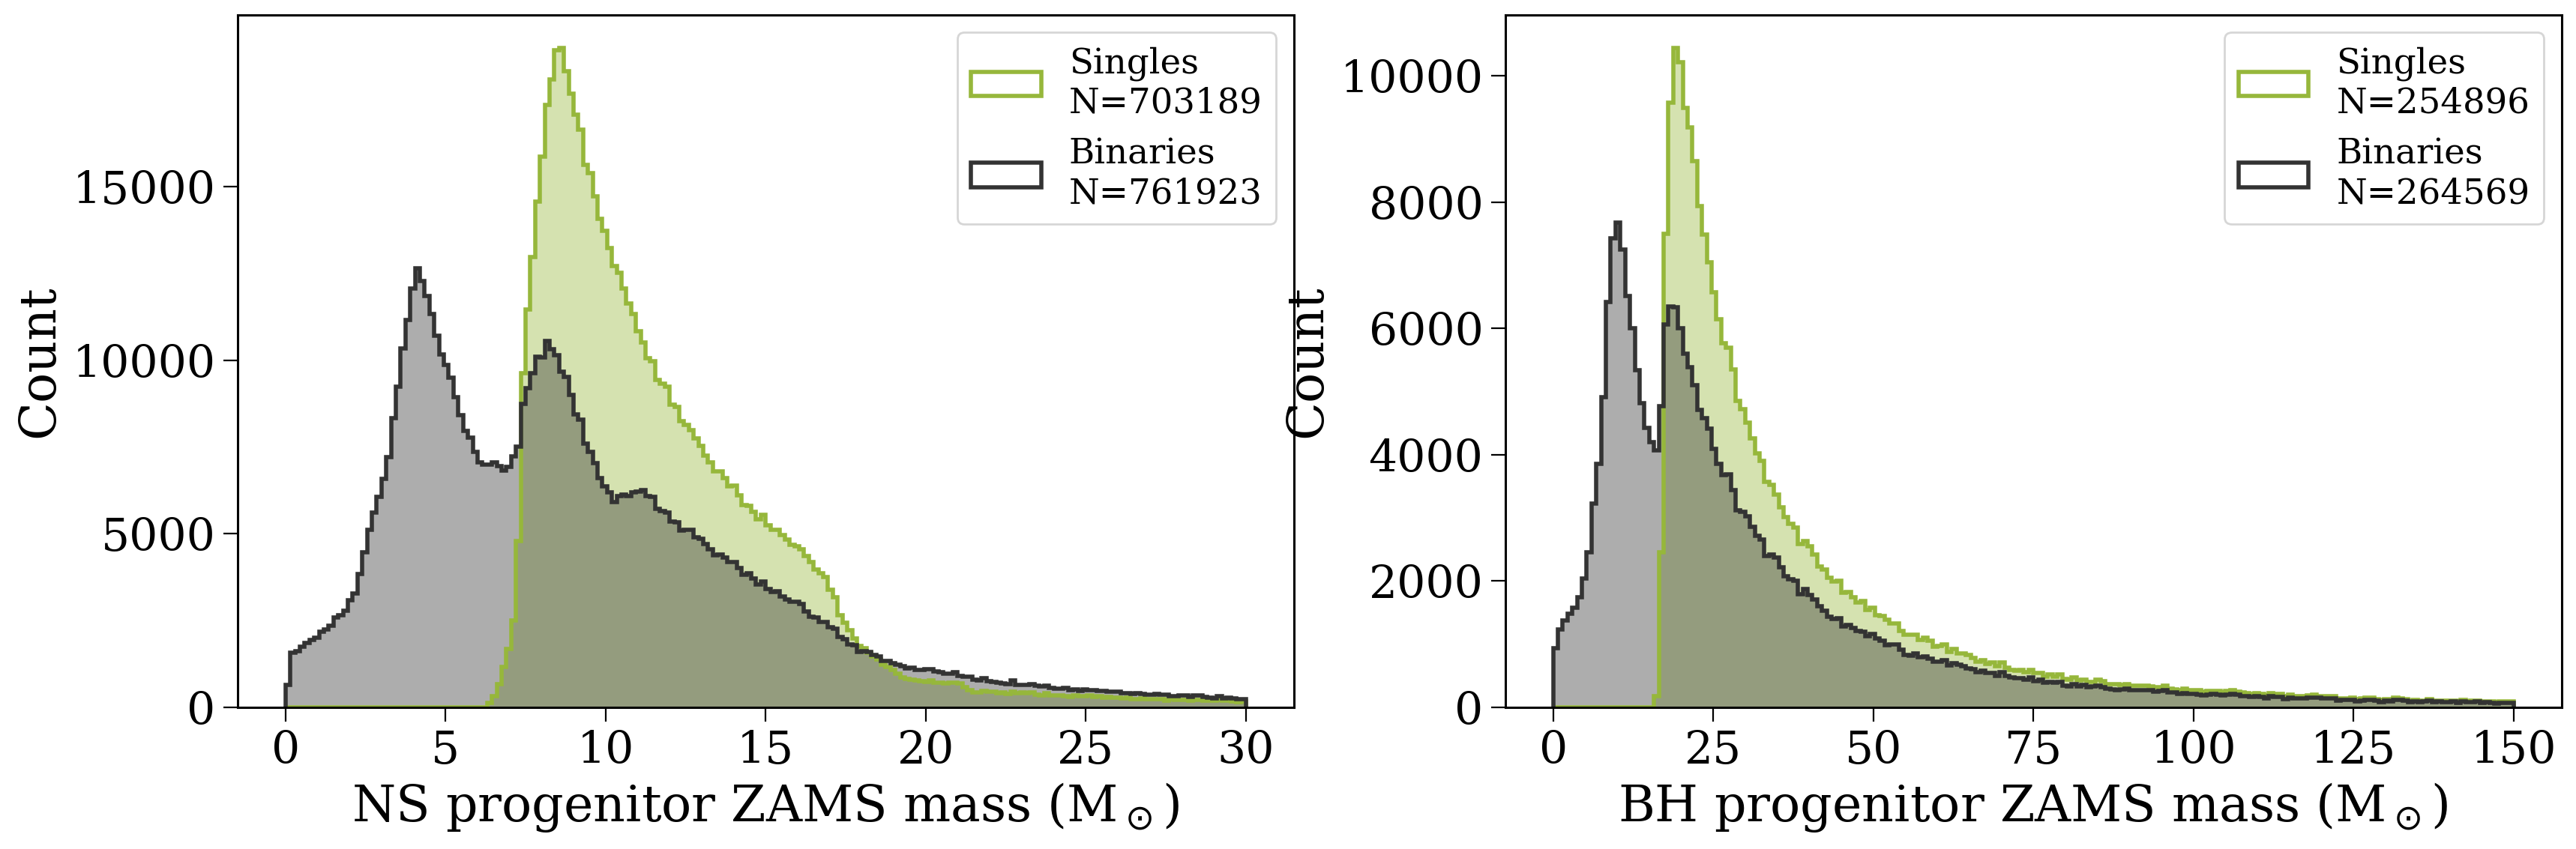

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    plotting.compare_table_quantity(
        pops=[singles_full_data, binaries_full_data],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} progenitor ZAMS mass (M$_\odot$)",
        ylabel="Count",
        density=False,
        ax=ax,
        fig=fig,
        show=False
    )
plt.show()

## Metallicity

Worrying spike up at $Z = 0.03$ for NSs

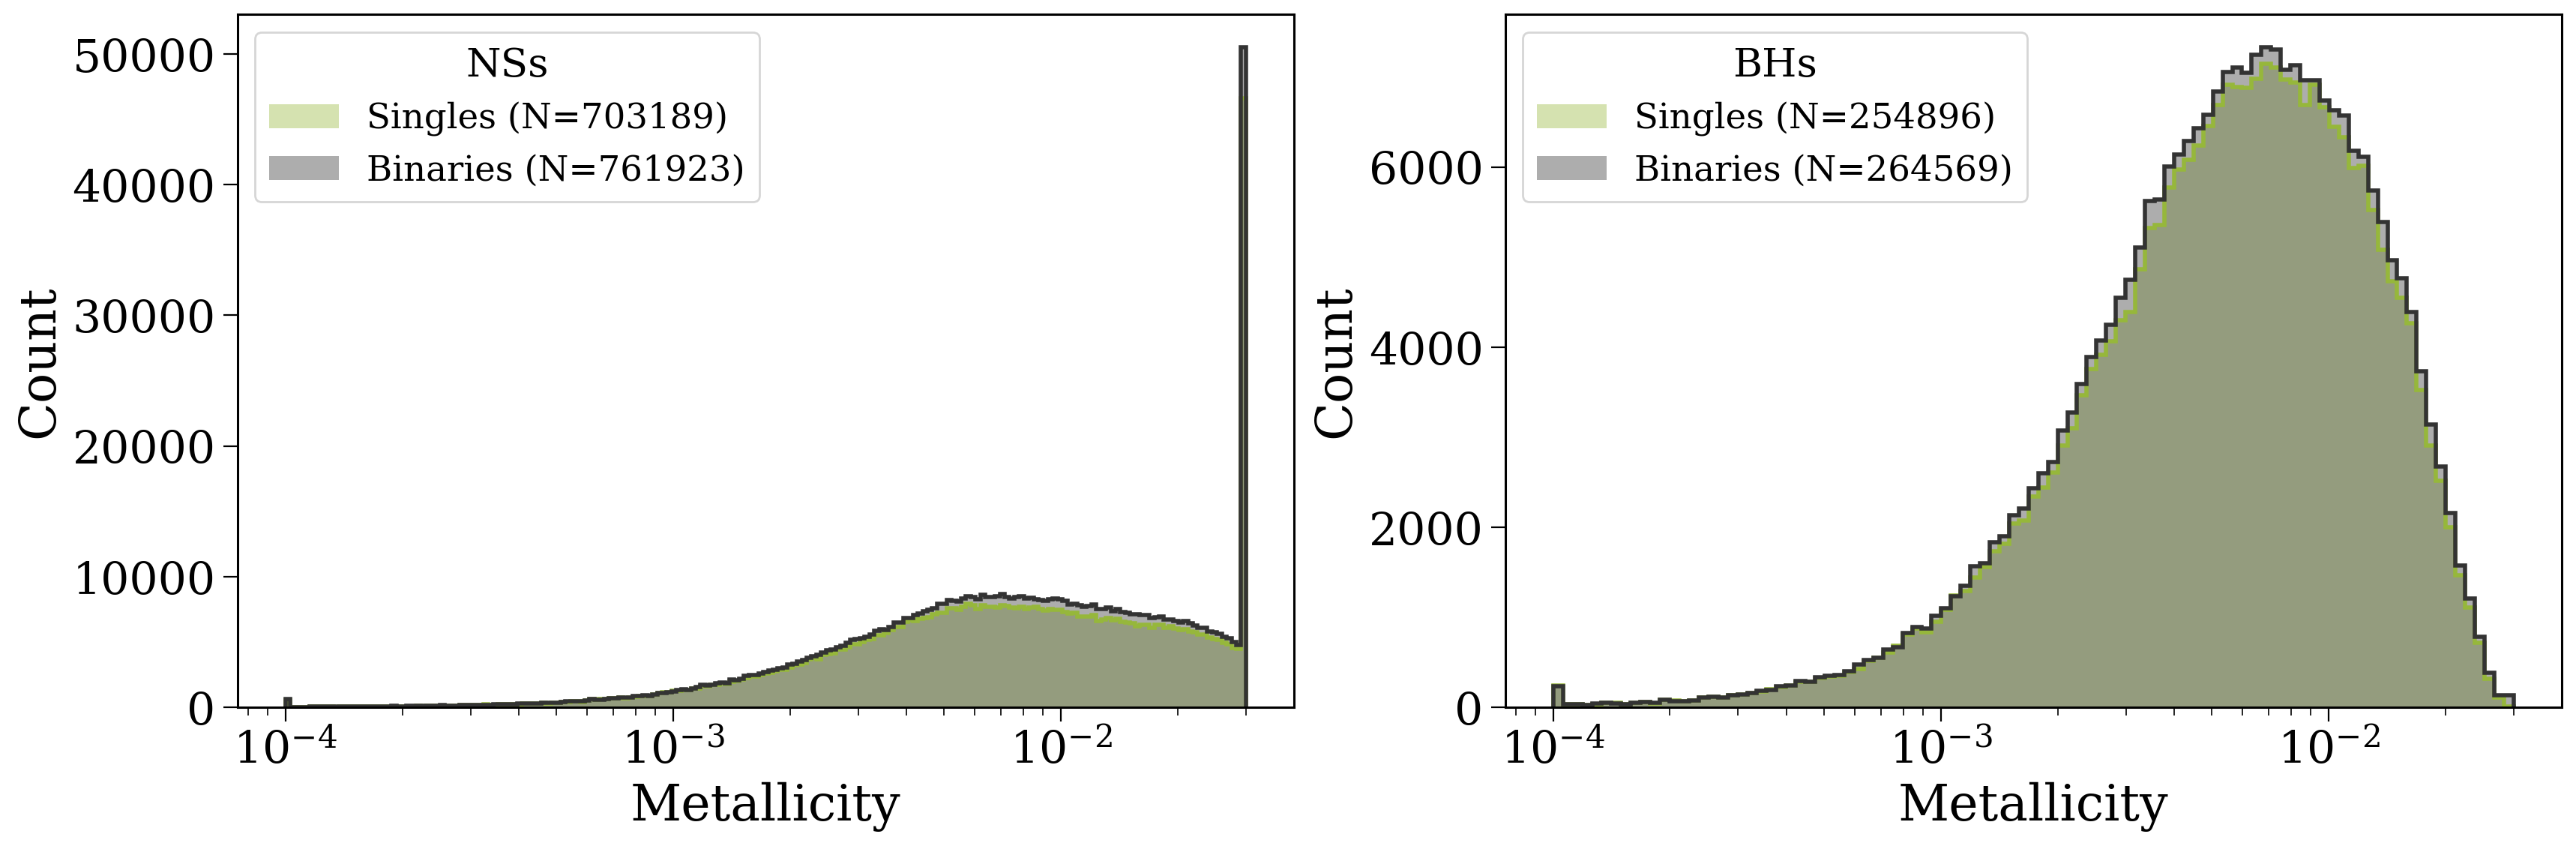

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.geomspace(1e-4, 0.03, 200), np.geomspace(1e-4, 0.03, 100)]):
    for pop in [singles_full_data, binaries_full_data]:
        init_Z = np.concatenate((
            pop.initC["metallicity"][pop.final_bpp["kstar_1"] == kstar],
            pop.initC["metallicity"][pop.final_bpp["kstar_2"] == kstar]
        ))

        ax.hist(init_Z, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(init_Z, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(init_Z)})")

    ax.set(
        xlabel=f"Metallicity",
        ylabel="Count",
        xscale='log'
    )
    ax.legend(title=f"{co_type}s")
plt.show()

## Delay time

Reproduces Wagg+25

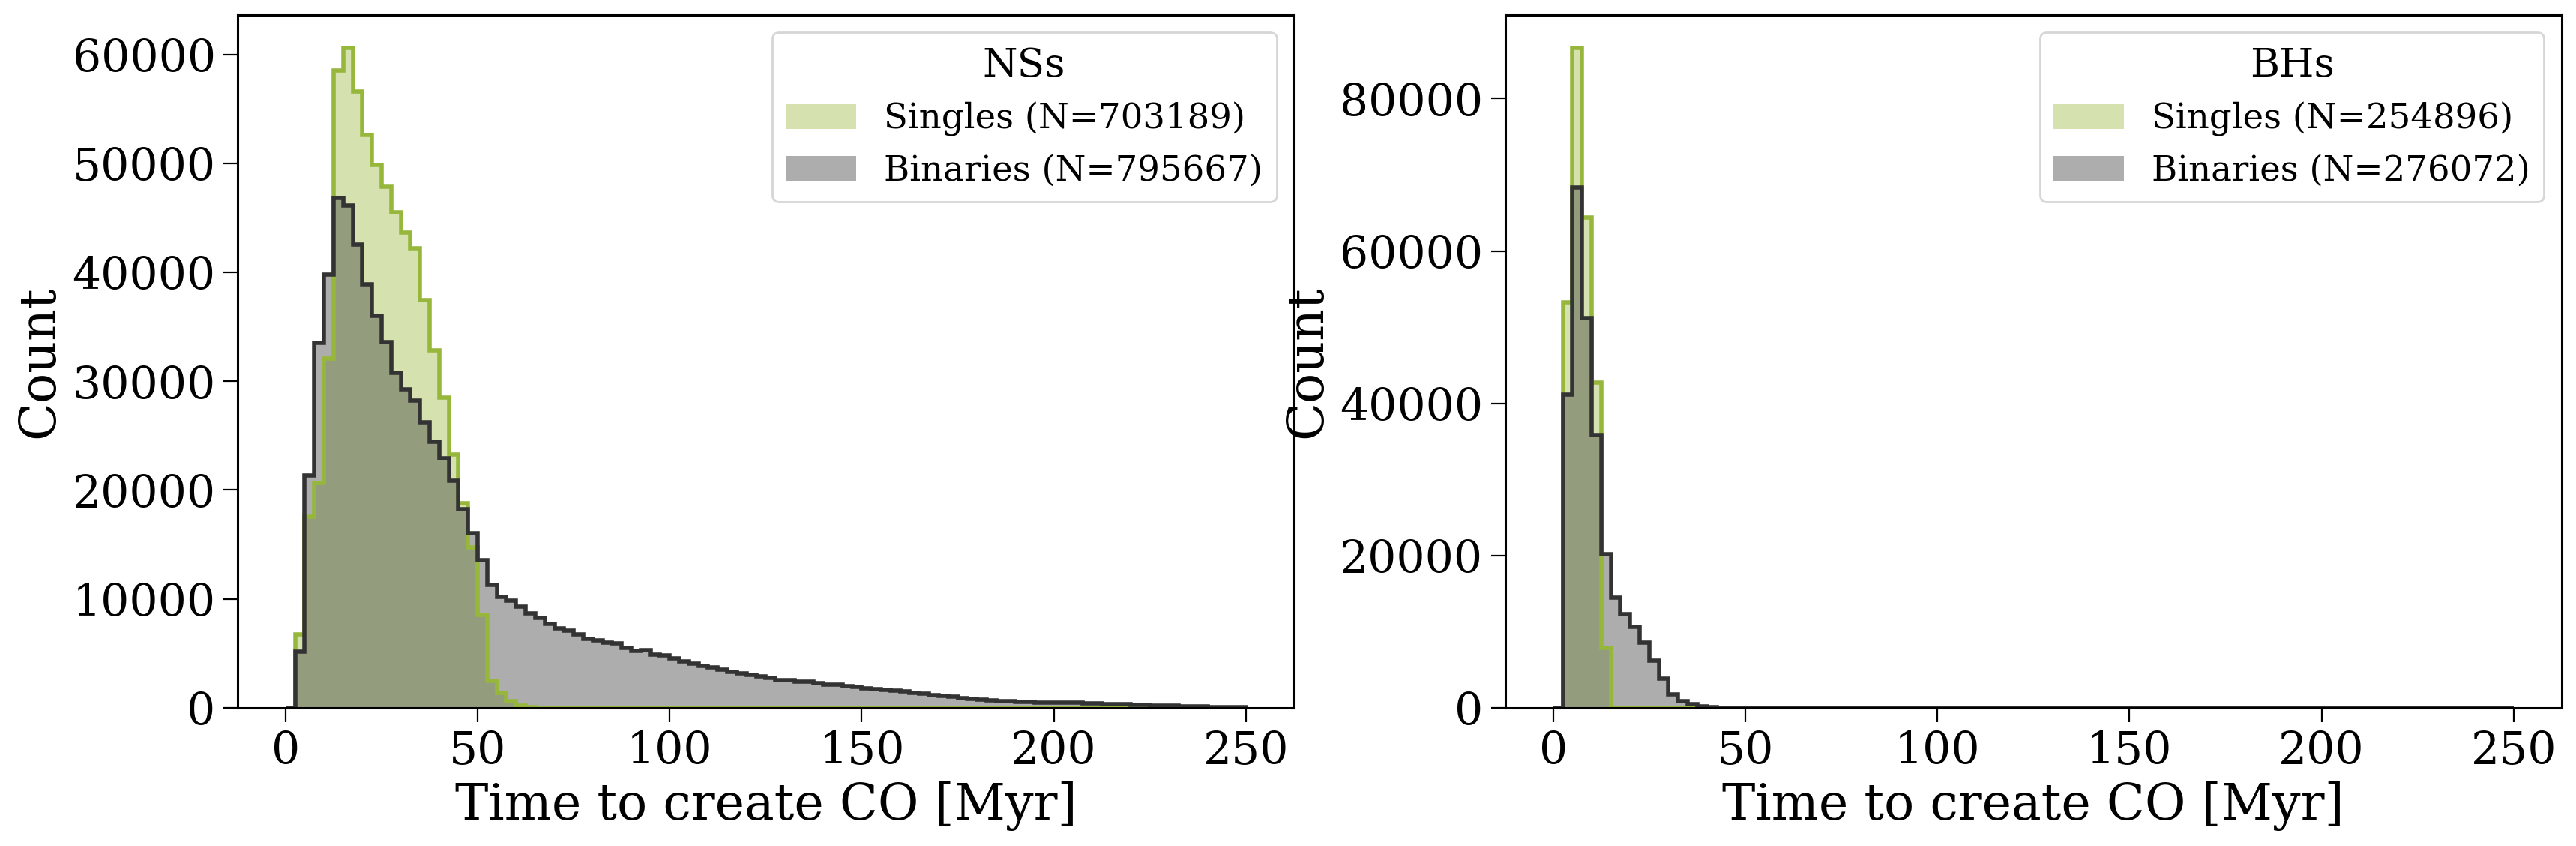

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 250, 101), np.linspace(0, 250, 101)]):
    for pop in [singles_full_data, binaries_full_data]:
        co_form_time = np.concatenate((
            pop.bpp[pop.bpp["kstar_1"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
            pop.bpp[pop.bpp["kstar_2"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
        ))

        ax.hist(co_form_time, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(co_form_time, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(co_form_time)})")

    ax.set(
        xlabel=f"Time to create CO [Myr]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s")
plt.show()